In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

# Load the dataset robustly from project root or datasets folder
data_path = Path("datasets/phishing_url_features.csv")
if not data_path.exists():
    data_path = Path("phishing_url_features.csv")

df = pd.read_csv(data_path)

In [2]:

pd.set_option('display.max_columns', None)
df

,url,URLLength,Domain,DomainLength,TLD,TLDLength,NoOfSubDomain,NoOfLettersInURL,NoOfDigitsInURL,LetterRatioInURL,DigitRatioInURL,NoOfSpecialCharsInURL,PathLength,IsHTTPS,HasIPAddress,HasHyphenInDomain,HasSuspiciousKeyword,DomainEntropy,DomainHasNumber,label
0,https://blockchaoin.info/#/,27,blockchaoin,11,info,4,0,20,0,0.740741,0.000000,7,1,1,0,0,0,3.095795,0,1
1,https://www.insects.org/ced4/crush_freaks.html,46,insects,7,org,3,0,36,1,0.782609,0.021739,9,23,1,0,0,0,2.521641,0,0
2,https://www.elpasotimes.com/story/opinion/edit...,118,elpasotimes,11,com,3,0,83,16,0.703390,0.135593,19,91,1,0,0,0,3.095795,0,0
3,http://direct-certs.bankofamerica.com.techdbas...,147,techdbaseurl46,14,cn,2,3,71,63,0.482993,0.428571,13,22,0,0,0,1,3.664498,1,1
4,https://gotham-magazine.com/lalique-unveils-ep...,53,gotham-magazine,15,com,3,0,44,0,0.830189,0.000000,9,26,1,0,1,0,3.323231,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5183045,http://myapple-login.com.daflonpneus.com.br/up...,90,daflonpneus,11,br,2,2,57,21,0.633333,0.233333,12,47,0,0,0,1,3.277613,0,1
5183046,https://www.portoseguro.com.br/seguro-imobiliaria,49,portoseguro,11,br,2,0,41,0,0.836735,0.000000,8,19,1,0,0,0,2.845351,0,0
5183047,http://shopping4u.in/js/ceo/Arch/sb/,36,shopping4u,10,in,2,0,26,1,0.722222,0.027778,9,16,0,0,0,0,3.121928,1,1
5183048,http://allfreecounter.com/,26,allfreecounter,14,com,3,0,21,0,0.807692,0.000000,5,1,0,0,0,1,3.182006,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5183050 entries, 0 to 5183049
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   url                    str    
 1   URLLength              int64  
 2   Domain                 str    
 3   DomainLength           int64  
 4   TLD                    str    
 5   TLDLength              int64  
 6   NoOfSubDomain          int64  
 7   NoOfLettersInURL       int64  
 8   NoOfDigitsInURL        int64  
 9   LetterRatioInURL       float64
 10  DigitRatioInURL        float64
 11  NoOfSpecialCharsInURL  int64  
 12  PathLength             int64  
 13  IsHTTPS                int64  
 14  HasIPAddress           int64  
 15  HasHyphenInDomain      int64  
 16  HasSuspiciousKeyword   int64  
 17  DomainEntropy          float64
 18  DomainHasNumber        int64  
 19  label                  int64  
dtypes: float64(3), int64(14), str(3)
memory usage: 790.9 MB


**DATA SPLITTING**


In [4]:
selected_features_extended = [

    "DomainLength",
    "PathLength",
    "TLDLength",
    "NoOfSubDomain",
    "LetterRatioInURL",
    "NoOfSpecialCharsInURL",
    "IsHTTPS",
    "HasIPAddress",
    "HasHyphenInDomain",
    "NoOfDigitsInURL",
    "HasSuspiciousKeyword",
    "DomainEntropy",
    "DomainHasNumber",
]

X = df[selected_features_extended]

y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified split (recommended)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Random split (for comparison)
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=None,
)

print(f"Stratified split shapes — train: {X_train.shape}, test: {X_test.shape}")
print(f"Random split shapes     — train: {X_train_rand.shape}, test: {X_test_rand.shape}")

print("\nClass distribution (percent) — Stratified split")
print("Train:")
display((y_train.value_counts(normalize=True) * 100).round(2))
print("Test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution (percent) — Random split")
print("Train:")
display((y_train_rand.value_counts(normalize=True) * 100).round(2))
print("Test:")
display((y_test_rand.value_counts(normalize=True) * 100).round(2))

X_train shape: (4146440, 13)
X_test shape: (1036610, 13)
y_train shape: (4146440,)
y_test shape: (1036610,)

Train distribution (%):
label
0    55.6
1    44.4
Name: proportion, dtype: float64

Test distribution (%):
label
0    55.6
1    44.4
Name: proportion, dtype: float64


In [6]:
import numpy as np

num_cols = X_train.select_dtypes(include=['number']).columns

skewness_train = X_train[num_cols].skew()

skewed_features = skewness_train[
    (skewness_train > 0.5) | (skewness_train < -0.5)
].index

print("skewed features:")
print(skewed_features)

skewed features:
Index(['DomainLength', 'PathLength', 'TLDLength', 'NoOfSubDomain',
       'LetterRatioInURL', 'NoOfSpecialCharsInURL', 'HasIPAddress',
       'HasHyphenInDomain', 'NoOfDigitsInURL', 'HasSuspiciousKeyword',
       'DomainEntropy', 'DomainHasNumber'],
      dtype='str')


In [7]:
X_train_log = X_train.copy()
X_test_log = X_test.copy()

for col in skewed_features:
    
    if (X_train_log[col] < 0).any():
        
        shift = abs(X_train_log[col].min()) + 1
        
        X_train_log[col] = np.log1p(X_train_log[col] + shift)
        X_test_log[col] = np.log1p(X_test_log[col] + shift)
    
    else:
        
        X_train_log[col] = np.log1p(X_train_log[col])
        X_test_log[col] = np.log1p(X_test_log[col])

**SCALING**


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = X_train_log.select_dtypes(include=['number']).columns

X_train_scaled = X_train_log.copy()
X_test_scaled = X_test_log.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_log[num_cols])
    
X_test_scaled[num_cols] = scaler.transform(X_test_log[num_cols])

In [9]:
# Use scaled features for linear models, log-transformed features for tree models
X_train_linear = X_train_scaled.copy()
X_test_linear = X_test_scaled.copy()

X_train_tree = X_train_log.copy()
X_test_tree = X_test_log.copy()

print("Linear train/test:", X_train_linear.shape, X_test_linear.shape)
print("Tree train/test:", X_train_tree.shape, X_test_tree.shape)

Linear train/test: (4146440, 13) (1036610, 13)
Tree train/test: (4146440, 13) (1036610, 13)


**FEATURE SELECTION**


In [10]:
# hanya kolom numerik
X_features = X_train_log.select_dtypes(include=['number'])

print(X_features.columns)

Index(['DomainLength', 'PathLength', 'TLDLength', 'NoOfSubDomain',
       'LetterRatioInURL', 'NoOfSpecialCharsInURL', 'IsHTTPS', 'HasIPAddress',
       'HasHyphenInDomain', 'NoOfDigitsInURL', 'HasSuspiciousKeyword',
       'DomainEntropy', 'DomainHasNumber'],
      dtype='str')


In [11]:
spearman_corr_table = X_features.corr(method='spearman')

print("=== Spearman Feature Correlation ===")
display(spearman_corr_table)

=== Spearman Feature Correlation ===


,DomainLength,PathLength,TLDLength,NoOfSubDomain,LetterRatioInURL,NoOfSpecialCharsInURL,IsHTTPS,HasIPAddress,HasHyphenInDomain,NoOfDigitsInURL,HasSuspiciousKeyword,DomainEntropy,DomainHasNumber
DomainLength,1.000000,0.056202,0.171263,-0.139381,0.182730,0.014186,-0.071191,0.133942,0.196128,0.000655,0.085836,0.883010,-0.002969
PathLength,0.056202,1.000000,-0.027661,-0.181923,0.053865,0.646694,0.119781,0.011015,-0.009609,0.259600,0.059471,0.044195,-0.086569
TLDLength,0.171263,-0.027661,1.000000,-0.068667,0.148567,-0.089128,0.089666,-0.178244,-0.027491,-0.094790,-0.021499,0.194185,-0.051244
NoOfSubDomain,-0.139381,-0.181923,-0.068667,1.000000,-0.164692,0.097726,-0.324671,-0.063638,0.011192,0.229681,0.382301,-0.118068,0.202975
LetterRatioInURL,0.182730,0.053865,0.148567,-0.164692,1.000000,-0.176154,0.187620,-0.199657,-0.046379,-0.812554,-0.118652,0.192546,-0.248861
NoOfSpecialCharsInURL,0.014186,0.646694,-0.089128,0.097726,-0.176154,1.000000,0.035952,0.036571,0.073583,0.443734,0.238327,0.004233,0.010935
IsHTTPS,-0.071191,0.119781,0.089666,-0.324671,0.187620,0.035952,1.000000,-0.109538,-0.059303,-0.155819,-0.319588,-0.045959,-0.162891
HasIPAddress,0.133942,0.011015,-0.178244,-0.063638,-0.199657,0.036571,-0.109538,1.000000,-0.042714,0.164798,0.087789,-0.034487,0.436304
HasHyphenInDomain,0.196128,-0.009609,-0.027491,0.011192,-0.046379,0.073583,-0.059303,-0.042714,1.000000,0.017743,0.070275,0.219656,0.007302
NoOfDigitsInURL,0.000655,0.259600,-0.094790,0.229681,-0.812554,0.443734,-0.155819,0.164798,0.017743,1.000000,0.219716,-0.026891,0.238992


In [12]:
pearson_corr_table = X_features.corr(method='pearson')

print("=== Pearson Feature Correlation ===")
display(pearson_corr_table)

=== Pearson Feature Correlation ===


,DomainLength,PathLength,TLDLength,NoOfSubDomain,LetterRatioInURL,NoOfSpecialCharsInURL,IsHTTPS,HasIPAddress,HasHyphenInDomain,NoOfDigitsInURL,HasSuspiciousKeyword,DomainEntropy,DomainHasNumber
DomainLength,1.000000,0.051963,0.172348,-0.088618,0.110725,0.022372,-0.071032,0.113460,0.202576,0.015927,0.091741,0.872398,-0.007152
PathLength,0.051963,1.000000,-0.032321,-0.152196,0.009174,0.560448,0.126927,0.015118,-0.016406,0.260567,0.067067,0.048903,-0.087101
TLDLength,0.172348,-0.032321,1.000000,-0.064662,0.145079,-0.077361,0.085675,-0.172170,-0.024128,-0.090084,-0.018761,0.189800,-0.041755
NoOfSubDomain,-0.088618,-0.152196,-0.064662,1.000000,-0.176151,0.168246,-0.299650,-0.057016,0.013357,0.288467,0.410151,-0.070902,0.178059
LetterRatioInURL,0.110725,0.009174,0.145079,-0.176151,1.000000,-0.183285,0.194363,-0.307617,-0.036815,-0.784533,-0.129150,0.123900,-0.284600
NoOfSpecialCharsInURL,0.022372,0.560448,-0.077361,0.168246,-0.183285,1.000000,0.028002,0.036036,0.068220,0.471224,0.232188,0.017989,0.009614
IsHTTPS,-0.071032,0.126927,0.085675,-0.299650,0.194363,0.028002,1.000000,-0.109538,-0.059303,-0.167861,-0.319588,-0.039864,-0.162891
HasIPAddress,0.113460,0.015118,-0.172170,-0.057016,-0.307617,0.036036,-0.109538,1.000000,-0.042714,0.155502,0.087789,0.004665,0.436304
HasHyphenInDomain,0.202576,-0.016406,-0.024128,0.013357,-0.036815,0.068220,-0.059303,-0.042714,1.000000,0.022066,0.070275,0.193442,0.007302
NoOfDigitsInURL,0.015927,0.260567,-0.090084,0.288467,-0.784533,0.471224,-0.167861,0.155502,0.022066,1.000000,0.246129,-0.000799,0.221355


In [13]:
import numpy as np
import pandas as pd

threshold = 0.8

corr_matrix = X_features.corr(method="spearman")

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) >= threshold:
            
            high_corr.append({
                "feature_1": corr_matrix.columns[i],
                "feature_2": corr_matrix.columns[j],
                "correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr).sort_values(
    by="correlation",
    key=abs,
    ascending=False
)

print("Highly correlated features:")
display(high_corr_df)

Highly correlated features:


,feature_1,feature_2,correlation
1,DomainEntropy,DomainLength,0.883010
0,NoOfDigitsInURL,LetterRatioInURL,-0.812554


**MODELLING**


In [14]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [15]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test)[:,1]

    results = {

        "accuracy": accuracy_score(y_test, y_pred),
        
        "precision": precision_score(y_test, y_pred),
        
        "recall": recall_score(y_test, y_pred),
        
        "f1": f1_score(y_test, y_pred),
        
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    return results

In [16]:
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_results = evaluate_model(
    logreg_model,
    X_train_linear,
    X_test_linear,
    y_train,
    y_test
)

logreg_results

{'accuracy': 0.8722586122070981,
 'precision': 0.8594420930283558,
 'recall': 0.8515390398546788,
 'f1': 0.8554723142678768,
 'roc_auc': 0.9557774882004269}

In [17]:
xgb_model = XGBClassifier(

    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
    tree_method="hist"
 )

xgb_results = evaluate_model(
    xgb_model,
    X_train_tree,
    X_test_tree,
    y_train,
    y_test
)

xgb_results

{'accuracy': 0.9062656158053656,
 'precision': 0.8848182411749244,
 'recall': 0.9069318720095954,
 'f1': 0.895738594296236,
 'roc_auc': 0.9736915396759613}

In [18]:
lgb_model = LGBMClassifier(

    n_estimators=200,
    learning_rate=0.05,
    
    num_leaves=31,
    
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
 )

lgb_results = evaluate_model(
    lgb_model,
    X_train_tree,
    X_test_tree,
    y_train,
    y_test
)

lgb_results

[LightGBM] [Info] Number of positive: 1840888, number of negative: 2305552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 4146440, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225072
[LightGBM] [Info] Start training from score -0.225072


{'accuracy': 0.9080628201541563,
 'precision': 0.8885845779673687,
 'recall': 0.9065929051631604,
 'f1': 0.8974984162766961,
 'roc_auc': 0.9743317390437869}

In [19]:
cat_model = CatBoostClassifier(

    iterations=200,
    depth=6,
    learning_rate=0.05,

    random_state=42,
    verbose=0,
    thread_count=-1
 )

cat_results = evaluate_model(
    cat_model,
    X_train_tree,
    X_test_tree,
    y_train,
    y_test
)

cat_results

{'accuracy': 0.9043294971107746,
 'precision': 0.8821651533851427,
 'recall': 0.9054564970818431,
 'f1': 0.8936590910309405,
 'roc_auc': 0.9722365933822952}

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
 )

rf_results = evaluate_model(
    rf_model,
    X_train_tree,
    X_test_tree,
    y_train,
    y_test
)

rf_results

{'accuracy': 0.9271992359710981,
 'precision': 0.9193745285856917,
 'recall': 0.916386005014971,
 'f1': 0.9178778342191288,
 'roc_auc': 0.9809472122556686}

In [21]:
results_df = pd.DataFrame({

    "Logistic Regression": logreg_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
    "LightGBM": lgb_results,
    "CatBoost": cat_results

}).T

results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.872259,0.859442,0.851539,0.855472,0.955777
Random Forest,0.927199,0.919375,0.916386,0.917878,0.980947
XGBoost,0.906266,0.884818,0.906932,0.895739,0.973692
LightGBM,0.908063,0.888585,0.906593,0.897498,0.974332
CatBoost,0.904329,0.882165,0.905456,0.893659,0.972237


In [22]:
from sklearn.base import clone

# Compare preprocessing strategies empirically per model
feature_sets = {
    "raw": (X_train, X_test),
    "log": (X_train_log, X_test_log),
    "log_scale": (X_train_scaled, X_test_scaled),
}

compare_models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=150,
        depth=6,
        learning_rate=0.05,
        random_state=42,
        verbose=0,
        thread_count=-1
    ),
}

comparison_rows = []

for fs_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in compare_models.items():
        metrics = evaluate_model(clone(model), X_tr, X_te, y_train, y_test)
        comparison_rows.append({
            "feature_set": fs_name,
            "model": model_name,
            **metrics,
        })

preprocess_compare_df = pd.DataFrame(comparison_rows)

roc_auc_pivot = preprocess_compare_df.pivot(
    index="model",
    columns="feature_set",
    values="roc_auc"
).round(5)

best_feature_set_by_model = roc_auc_pivot.idxmax(axis=1).rename("best_feature_set")

print("ROC-AUC by model and preprocessing strategy:")
display(roc_auc_pivot)

print("Best preprocessing per model (by ROC-AUC):")
display(best_feature_set_by_model.to_frame())

[LightGBM] [Info] Number of positive: 1840888, number of negative: 2305552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 4146440, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225072
[LightGBM] [Info] Start training from score -0.225072
[LightGBM] [Info] Number of positive: 1840888, number of negative: 2305552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 4146440, number of used features: 13
[Light

feature_set,log,log_scale,raw
model,,,
CatBoost,0.97010,0.97010,0.97010
LightGBM,0.97357,0.97358,0.97357
LogReg,0.95577,0.95578,0.95785
RandomForest,0.98078,0.98078,0.98078
XGBoost,0.97252,0.97252,0.97252


Best preprocessing per model (by ROC-AUC):


,best_feature_set
model,
CatBoost,log
LightGBM,log_scale
LogReg,raw
RandomForest,log
XGBoost,log


In [26]:
import optuna

In [27]:
# Faster stratified CV than full StratifiedKFold
skf = StratifiedShuffleSplit(
    n_splits=3,
    test_size=0.2,
    random_state=42
)

In [28]:
def objective_logreg(trial):

    params = {

        "C": trial.suggest_float("C", 0.01, 10, log=True),

        "solver": trial.suggest_categorical(
            "solver",
            ["liblinear","lbfgs"]
        ),

        "max_iter": 1000
    }

    scores = []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):

        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LogisticRegression(**params, class_weight='balanced', random_state=42)

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        score = recall_score(y_val, preds)

        scores.append(score)

    return np.mean(scores)


study_logreg = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
 )

study_logreg.optimize(objective_logreg, n_trials=10)

best_logreg_params = study_logreg.best_params


[I 2026-03-27 23:32:46,593] A new study created in memory with name: no-name-ef318555-6b57-4084-adf6-c6d2987e7b24
[I 2026-03-27 23:33:08,218] Trial 0 finished with value: 0.8899200929984953 and parameters: {'C': 0.13292918943162169, 'solver': 'liblinear'}. Best is trial 0 with value: 0.8899200929984953.
[I 2026-03-27 23:33:29,693] Trial 1 finished with value: 0.8899128501250301 and parameters: {'C': 0.6251373574521749, 'solver': 'liblinear'}. Best is trial 0 with value: 0.8899200929984953.
[I 2026-03-27 23:33:47,970] Trial 2 finished with value: 0.8899400109005245 and parameters: {'C': 0.014936568554617643, 'solver': 'liblinear'}. Best is trial 2 with value: 0.8899400109005245.
[I 2026-03-27 23:33:57,423] Trial 3 finished with value: 0.8897815730434736 and parameters: {'C': 1.3311216080736885, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.8899400109005245.
[I 2026-03-27 23:34:19,849] Trial 4 finished with value: 0.8899155662025796 and parameters: {'C': 3.142880890840109, 'solver': 

In [30]:
def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 50, 200),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2),

        "subsample": trial.suggest_float("subsample", 0.6, 1),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1
        ),

        "gamma": trial.suggest_float("gamma", 0, 2),

        "eval_metric": "logloss",

        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    scores = []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):

        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBClassifier(**params)

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        score = recall_score(y_val, preds)

        scores.append(score)

    return np.mean(scores)


study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
 )

study_xgb.optimize(objective_xgb, n_trials=10)

best_xgb_params = study_xgb.best_params


[I 2026-03-27 23:38:50,776] A new study created in memory with name: no-name-0a3caaa4-bc4c-4ced-aa78-c9514c36d8dc
[I 2026-03-27 23:39:20,073] Trial 0 finished with value: 0.9148165651759023 and parameters: {'n_estimators': 106, 'max_depth': 10, 'learning_rate': 0.15175890952605292, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.3119890406724053}. Best is trial 0 with value: 0.9148165651759023.
[I 2026-03-27 23:39:34,624] Trial 1 finished with value: 0.9082807772327515 and parameters: {'n_estimators': 58, 'max_depth': 9, 'learning_rate': 0.1282007021137776, 'subsample': 0.8832290311184182, 'colsample_bytree': 0.608233797718321, 'gamma': 1.9398197043239886}. Best is trial 0 with value: 0.9148165651759023.
[I 2026-03-27 23:39:53,190] Trial 2 finished with value: 0.9023542960198601 and parameters: {'n_estimators': 175, 'max_depth': 4, 'learning_rate': 0.05272849409727812, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.721696897183815, 'gamma': 1

In [31]:
def objective_lgb(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 50, 200),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            64
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1
        ),

        "random_state": 42,
        "n_jobs": -1
    }

    scores = []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):

        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LGBMClassifier(**params)

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        score = recall_score(y_val, preds)

        scores.append(score)

    return np.mean(scores)


study_lgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
 )

study_lgb.optimize(objective_lgb, n_trials=10)

best_lgb_params = study_lgb.best_params


[I 2026-03-27 23:42:07,108] A new study created in memory with name: no-name-c92f8279-e6f9-4012-84bd-79288103c12e


[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225073
[LightGBM] [Info] Start training from score -0.225073
[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1216
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[Light

[I 2026-03-27 23:42:27,272] Trial 0 finished with value: 0.9105287840845099 and parameters: {'n_estimators': 106, 'learning_rate': 0.19063571821788408, 'num_leaves': 52, 'max_depth': 8, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481}. Best is trial 0 with value: 0.9105287840845099.


[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225073
[LightGBM] [Info] Start training from score -0.225073
[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1216
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[Light

[I 2026-03-27 23:42:40,572] Trial 1 finished with value: 0.9087062960488314 and parameters: {'n_estimators': 58, 'learning_rate': 0.1745734676972377, 'num_leaves': 47, 'max_depth': 10, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978}. Best is trial 0 with value: 0.9105287840845099.


...

[I 2026-03-27 23:44:21,141] Trial 7 finished with value: 0.9077149277432836 and parameters: {'n_estimators': 55, 'learning_rate': 0.18277087639496858, 'num_leaves': 31, 'max_depth': 9, 'subsample': 0.7246844304357644, 'colsample_bytree': 0.8080272084711243}. Best is trial 0 with value: 0.9105287840845099.


[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225073
[LightGBM] [Info] Start training from score -0.225073
[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1216
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[Light

[I 2026-03-27 23:44:48,239] Trial 8 finished with value: 0.9072133587558192 and parameters: {'n_estimators': 132, 'learning_rate': 0.04512234654985014, 'num_leaves': 63, 'max_depth': 10, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595}. Best is trial 0 with value: 0.9105287840845099.


[LightGBM] [Info] Number of positive: 1472710, number of negative: 1844442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1222
[LightGBM] [Info] Number of data points in the train set: 3317152, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225073
[LightGBM] [Info] Start training from score -0.225073
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

[I 2026-03-27 23:45:02,781] Trial 9 finished with value: 0.9068892401682519 and parameters: {'n_estimators': 140, 'learning_rate': 0.1851561046543922, 'num_leaves': 23, 'max_depth': 4, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.7301321323053057}. Best is trial 0 with value: 0.9105287840845099.


In [32]:
def objective_cat(trial):

    params = {

        "iterations": trial.suggest_int("iterations", 50, 200),

        "depth": trial.suggest_int("depth", 4, 10),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        "random_state": 42,

        "verbose": 0,
        "thread_count": -1
    }

    scores = []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):

        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)

        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)

        score = recall_score(y_val, preds)

        scores.append(score)

    return np.mean(scores)


study_cat = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
 )

study_cat.optimize(objective_cat, n_trials=10)

best_cat_params = study_cat.best_params


[I 2026-03-27 23:45:02,790] A new study created in memory with name: no-name-def1867f-e6ea-4641-ab81-21d165cefaf0
[I 2026-03-27 23:45:41,288] Trial 0 finished with value: 0.9091390577383764 and parameters: {'iterations': 106, 'depth': 10, 'learning_rate': 0.14907884894416698, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 0.9091390577383764.
[I 2026-03-27 23:45:58,445] Trial 1 finished with value: 0.8763650553083925 and parameters: {'iterations': 73, 'depth': 5, 'learning_rate': 0.021035886311957897, 'l2_leaf_reg': 8.795585311974417}. Best is trial 0 with value: 0.9091390577383764.
[I 2026-03-27 23:46:33,726] Trial 2 finished with value: 0.8914012606221267 and parameters: {'iterations': 140, 'depth': 8, 'learning_rate': 0.013911053916202466, 'l2_leaf_reg': 9.72918866945795}. Best is trial 0 with value: 0.9091390577383764.
[I 2026-03-27 23:47:07,339] Trial 3 finished with value: 0.8999840656783767 and parameters: {'iterations': 175, 'depth': 5, 'learning_rate': 0.0445467

In [36]:
def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    scores = []

    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        score = recall_score(y_val, preds)
        scores.append(score)

    return np.mean(scores)


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
 )
study_rf.optimize(objective_rf, n_trials=10)

best_rf_params = study_rf.best_params


[I 2026-03-28 00:00:38,445] A new study created in memory with name: no-name-f3dd0585-8fdb-417c-9af9-3272c6d829eb
[I 2026-03-28 00:04:56,345] Trial 0 finished with value: 0.9153787932286376 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.9153787932286376.
[I 2026-03-28 00:07:16,097] Trial 1 finished with value: 0.7935871598339208 and parameters: {'n_estimators': 227, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.9153787932286376.
[I 2026-03-28 00:14:35,155] Trial 2 finished with value: 0.9060608365156709 and parameters: {'n_estimators': 158, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.9153787932286376.
[I 2026-03-28 00:27:08,996] Trial 3 finished with value: 0.9106519129334182 a

In [37]:
best_models = {

    "LogReg":
    LogisticRegression(
        **best_logreg_params,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    "RandomForest":
    RandomForestClassifier(
        **best_rf_params,
        random_state=42,
        n_jobs=-1,
    ),

    "XGBoost":
    XGBClassifier(
        **best_xgb_params,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LightGBM":
    LGBMClassifier(
        **best_lgb_params,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost":
    CatBoostClassifier(
        **best_cat_params,
        random_state=42,
        verbose=0,
        thread_count=-1
    )
}

In [38]:
final_results = {}

for name, model in best_models.items():

    # Use log+scale for all final evaluations (consistent with Optuna runs)
    X_train_eval, X_test_eval = X_train_scaled, X_test_scaled

    model.fit(X_train_eval, y_train)

    # prefer predict_proba where available
    if hasattr(model, "predict_proba"):
        preds = model.predict_proba(X_test_eval)[:,1]
    else:
        preds = model.predict(X_test_eval)

    score = roc_auc_score(y_test, preds)

    final_results[name] = score


pd.Series(final_results).sort_values(ascending=False)

[LightGBM] [Info] Number of positive: 1840888, number of negative: 2305552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1228
[LightGBM] [Info] Number of data points in the train set: 4146440, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.443968 -> initscore=-0.225072
[LightGBM] [Info] Start training from score -0.225072


XGBoost         0.979276
RandomForest    0.979167
LightGBM        0.976661
CatBoost        0.975390
LogReg          0.955783
dtype: float64

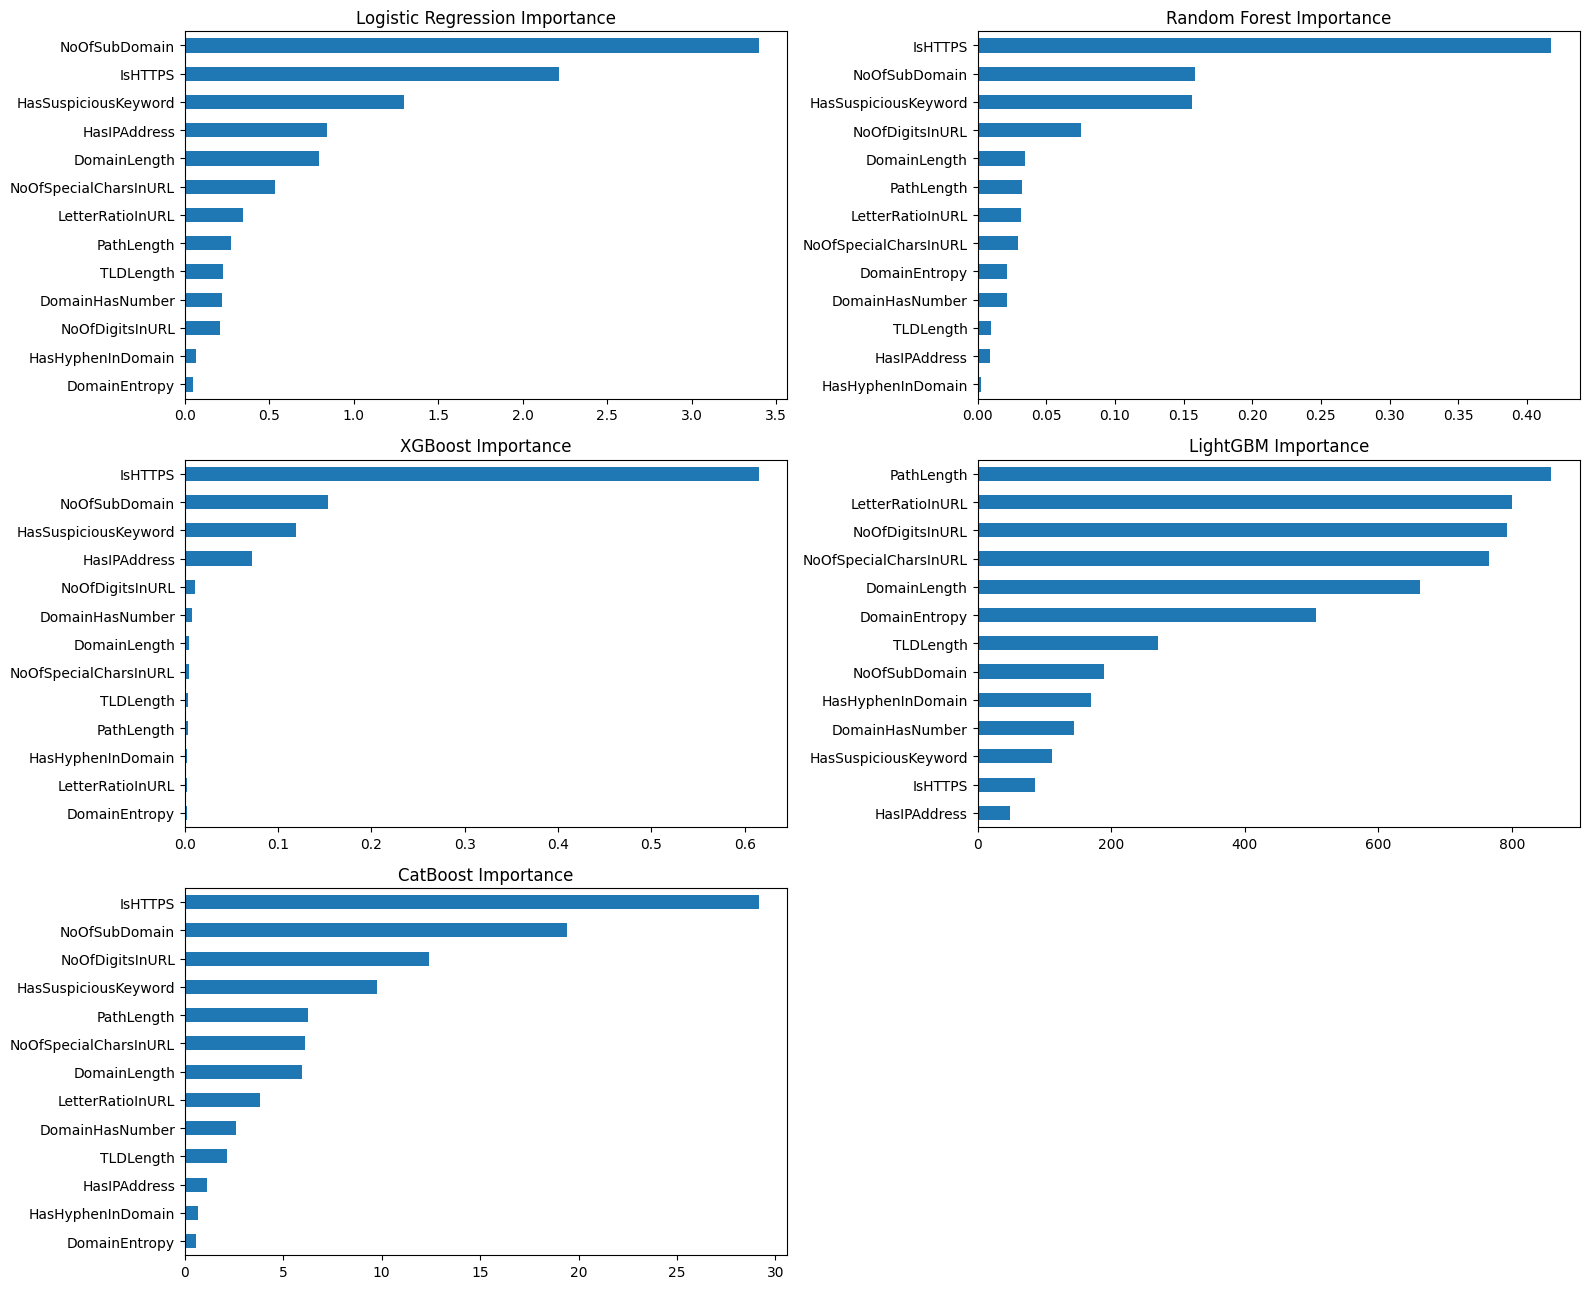

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ambil importance
logreg_importance = np.abs(best_models["LogReg"].coef_[0])

rf_importance = best_models["RandomForest"].feature_importances_

xgb_importance = best_models["XGBoost"].feature_importances_

lgb_importance = best_models["LightGBM"].feature_importances_

cat_importance = best_models["CatBoost"].feature_importances_


fig, axes = plt.subplots(3, 2, figsize=(16, 13))

pd.Series(
    logreg_importance,
    index=X_train.columns
).sort_values().plot.barh(ax=axes[0,0])
axes[0,0].set_title("Logistic Regression Importance")

pd.Series(
    rf_importance,
    index=X_train.columns
).sort_values().plot.barh(ax=axes[0,1])
axes[0,1].set_title("Random Forest Importance")

pd.Series(
    xgb_importance,
    index=X_train.columns
).sort_values().plot.barh(ax=axes[1,0])
axes[1,0].set_title("XGBoost Importance")

pd.Series(
    lgb_importance,
    index=X_train.columns
).sort_values().plot.barh(ax=axes[1,1])
axes[1,1].set_title("LightGBM Importance")

pd.Series(
    cat_importance,
    index=X_train.columns
).sort_values().plot.barh(ax=axes[2,0])
axes[2,0].set_title("CatBoost Importance")

axes[2,1].axis("off")

plt.tight_layout()
plt.show()

In [40]:
# Save best model (re-fit on training data and write to disk)
import joblib
from pathlib import Path
import datetime
import pandas as pd

# Ensure `final_results` and `best_models` exist
if 'final_results' in globals() and 'best_models' in globals():
    best_name = pd.Series(final_results).idxmax()
    best_model = best_models[best_name]

    # Re-fit on the full training set (log+scale) to be safe
    best_model.fit(X_train_scaled, y_train)

    out_dir = Path('models')
    out_dir.mkdir(exist_ok=True)
    ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = out_dir / f"best_model_{best_name}_{ts}.pkl"
    joblib.dump(best_model, filename)
    print(f"Saved best model '{best_name}' to {filename}")
else:
    print('final_results or best_models not found — run tuning and evaluation cells first.')

Saved best model 'XGBoost' to models/best_model_XGBoost_20260328_010917.pkl
